# Session 1A — Data preparation

Load and validate the paired Tonsil data, then apply the official DGAT quality-control and normalization workflow.

Work through the parts in order. Each part ends by writing its existing JSON checkpoint,
so the consolidation changes file organization without removing pause/resume milestones.


In [1]:
from pathlib import Path
import sys

# Locates the cloned tutorial in Google Colab after Session 0 setup.
candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
colab_root = Path("/content/ECCB-2026-Tutorial/hands-on_tutorial")
if colab_root.is_dir():
    candidates.insert(0, colab_root.resolve())

for candidate in candidates:
    if (candidate / "src" / "dgat_tutorial").is_dir():
        tutorial_root = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find hands-on_tutorial/. In Colab, run notebooks/session_00/00_colab_setup.ipynb first."
    )

sys.path.insert(0, str(tutorial_root / "src"))

from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint

paths = tutorial_paths(tutorial_root)
print(f"Tutorial root: {paths.root}")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial


## Session 1 · Part 1 — Build the tutorial data object

**Goal:** load paired spatial RNA and protein measurements into one validated object. We use the
lightweight `SpatialOmicsData` object. The
object plays the same teaching role: it keeps observations, modalities, and coordinates aligned.

By the end you should be able to explain why row identity and coordinate validation must happen
before normalization or graph construction. Every tutorial section uses the same **10x Genomics
CytAssist Tonsil** RNA/ADT pair downloaded during Session 0; there is no generated-data substitute.


### Dataset — 10x Genomics CytAssist Human Tonsil

This tutorial uses a **public Visium CytAssist FFPE Human Tonsil** sample with paired gene expression and protein (ADT) measurements (`CytAssist_FFPE_Protein_Expression_Human_Tonsil`).

| Item | Detail |
| --- | --- |
| Technology | 10x Genomics Visium CytAssist on FFPE tissue |
| Tissue | Human tonsil (immune secondary lymphoid organ with follicles / germinal centers) |
| Modalities | Spatial RNA + antibody-derived tags (proteins) on the same spots |
| Files | `Tonsil_RNA.h5ad`, `Tonsil_ADT.h5ad` (DGAT-packaged AnnData) |
| Approximate size | ~4,200 spots × ~18,000 genes × 35 proteins (before QC) |
| Why it is useful here | Paired RNA–protein labels let us validate imputed protein landscapes against measured ADT while still practicing an RNA→protein inference workflow |

Tonsil is a structured tissue: B- and T-cell zones create clear spatial protein patterns (for example immune markers), which makes QC failures, graph neighborhoods, and prediction errors easier to interpret visually. Downstream notebooks keep this same sample; there is no synthetic substitute.

### 1. Load all three linked tables


In [2]:
import numpy as np
import pandas as pd

from dgat_tutorial.data import find_dgat_h5ad_pair, load_tutorial_data
from dgat_tutorial.processing import validate_modalities

pair = find_dgat_h5ad_pair(paths.raw_data)
dataset = load_tutorial_data(paths.raw_data)
spots = dataset.spots.copy()
# Keep all feature columns; validate_modalities will fail if non-numeric values appear.
transcripts = dataset.transcripts.copy()
proteins = dataset.proteins.copy()
dropped_rna = [c for c in transcripts.columns if not pd.api.types.is_numeric_dtype(transcripts[c])]
dropped_protein = [c for c in proteins.columns if not pd.api.types.is_numeric_dtype(proteins[c])]
if dropped_rna or dropped_protein:
    raise TypeError(
        "Non-numeric feature columns detected; refuse silent drop. "
        f"RNA={dropped_rna}; protein={dropped_protein}"
    )
source = f"RNA={pair[0]}, ADT={pair[1]}"

print(type(dataset).__name__)
print(f"Source: {source}")
print(f"spots × genes: {transcripts.shape}; spots × proteins: {proteins.shape}")
display(spots.head(3), transcripts.iloc[:3, :5], proteins.iloc[:3, :5])


SpatialOmicsData
Source: RNA=/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT_assets/data/Tonsil_RNA.h5ad, ADT=/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT_assets/data/Tonsil_ADT.h5ad
spots × genes: (4194, 18085); spots × proteins: (4194, 35)


,pathology,x,y
AACACGTGCATCGCAC-1,GC,22149.0,28719.0
AACACTTGGCAAGGAA-1,GC,13164.0,19549.0
AACAGGAAGAGCATAG-1,GC,24877.0,26484.0


,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1
AACACGTGCATCGCAC-1,0.0,0.0,0.0,0.0,0.0
AACACTTGGCAAGGAA-1,0.0,0.0,0.0,0.0,0.0
AACAGGAAGAGCATAG-1,0.0,0.0,0.0,0.0,0.0


,CD163,CR2,PCNA,VIM,KRT5
AACACGTGCATCGCAC-1,19675.0,35856.0,57685.0,48611.0,4606.0
AACACTTGGCAAGGAA-1,23938.0,35784.0,76953.0,16984.0,2430.0
AACAGGAAGAGCATAG-1,20784.0,34129.0,82150.0,43890.0,887.0


### 2. Validate the object

DGAT assumes that row *i* in RNA, protein, and spatial coordinates is the same biological spot.
The next call checks ordered IDs, duplicate IDs, finite numeric x/y coordinates, finite values, and
non-negative abundance. A shape match alone is not sufficient.


In [3]:
validate_modalities(spots, transcripts, proteins)
xy = spots[["x", "y"]].to_numpy(dtype=float)
checks = pd.DataFrame({
    "check": [
        "ordered IDs match",
        "x/y columns present",
        "x/y finite numeric",
        "finite RNA",
        "finite protein",
        "non-negative values",
    ],
    "passed": [
        spots.index.equals(transcripts.index) and spots.index.equals(proteins.index),
        {"x", "y"}.issubset(spots.columns),
        bool(np.isfinite(xy).all()),
        np.isfinite(transcripts.to_numpy(dtype=float)).all(),
        np.isfinite(proteins.to_numpy(dtype=float)).all(),
        (transcripts.to_numpy(dtype=float) >= 0).all() and (proteins.to_numpy(dtype=float) >= 0).all(),
    ],
})
checks


,check,passed
0,ordered IDs match,True
1,x/y columns present,True
2,x/y finite numeric,True
3,finite RNA,True
4,finite protein,True
5,non-negative values,True


### 3. Record a reproducible input summary


In [4]:
summary = pd.DataFrame([{
    "source": source,
    "spots": len(spots),
    "genes": transcripts.shape[1],
    "proteins": proteins.shape[1],
    "has_xy_coordinates": {"x", "y"}.issubset(spots.columns),
    "all_validation_checks_passed": bool(checks["passed"].all()),
}])
summary_path = paths.results / "session01_dataset_summary.csv"
summary.to_csv(summary_path, index=False)
manifest = write_checkpoint("1.1", [summary_path], summary=summary.iloc[0].to_dict(), start=paths.root)
summary


,source,spots,genes,proteins,has_xy_coordinates,all_validation_checks_passed
0,RNA=/Users/zmengaf/Documents/ECCB tuto/hands-o...,4194,18085,35,True,True


### Check

Continue only when every validation row is `True`. If IDs disagree, fix the upstream pairing—never
sort modalities independently and hope they align.


## Session 1 · Part 2 — QC, filtering, and normalization

**Goal:** apply the official **paired CITE-seq / training** preprocessing from
`external/DGAT/utils/Preprocessing.py` (`qc_control_cytassist` + `normalize`):

- keep spots with ≥700 detected genes
- remove spots with mitochondrial UMIs ≥35%
- keep genes detected in ≥2.5% of spots (plus encoding genes matched to the protein panel)
- remove ADT isotype controls (`mouse_`/`rat_` prefixes)
- RNA: library-size normalize to 10,000 → `log1p` → gene-wise scale with clip at 10
- protein: CLR via ``muon.prot.pp.clr`` (default ``axis=0``: per protein across spots)

**Important:** ST-only inference uses a lighter path (`preprocess_ST`: min_genes=700 +
RNA normalize/scale; no MT filter, no gene-prevalence filter, no protein CLR). Session 2's
official prediction wrapper follows that inference path. This notebook teaches the
*training* CytAssist recipe used when both RNA and protein are observed.


### 1. Calculate spot-level QC metrics


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dgat_tutorial.data import load_tutorial_data
from dgat_tutorial.plotting import plot_qc_overview, plot_raw_vs_normalized
from dgat_tutorial.processing import (
    DGAT_MAX_MT_PCT,
    DGAT_MIN_CELLS_FRACTION,
    DGAT_MIN_GENES,
    calculate_qc_metrics,
    process_modalities_official_dgat,
    validate_modalities,
)

dataset = load_tutorial_data(paths.raw_data)
spots = dataset.spots.copy()
# Keep every gene/protein column; do not silently drop via select_dtypes.
transcripts = dataset.transcripts.apply(pd.to_numeric, errors="raise")
proteins = dataset.proteins.apply(pd.to_numeric, errors="raise")
validate_modalities(spots, transcripts, proteins)
qc_before = calculate_qc_metrics(transcripts, proteins)
qc_before.describe().T


,count,mean,std,min,25%,50%,75%,max
rna_total,4194.0,32952.847656,12169.653320,285.000000,24956.250000,31248.000000,39277.750000,1.354540e+05
genes_detected,4194.0,8158.204578,1033.864008,273.000000,7708.000000,8275.000000,8794.750000,1.112400e+04
mt_pct,4194.0,2.707051,0.664100,0.595766,2.316934,2.765792,3.158808,4.766917e+00
protein_total,4194.0,759242.062500,207600.890625,135000.000000,619976.500000,743831.500000,877640.000000,1.968091e+06
proteins_detected,4194.0,34.989032,0.338870,20.000000,35.000000,35.000000,35.000000,3.500000e+01


#### Figure 1 — RNA and protein QC distributions


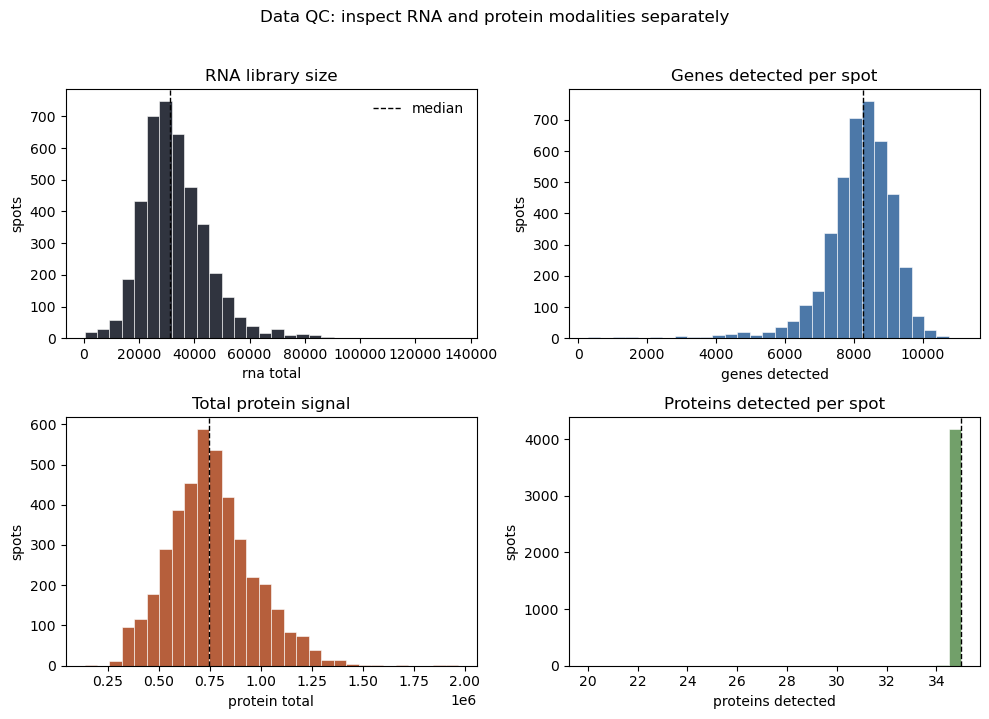

In [7]:
qc_figure, _ = plot_qc_overview(qc_before)
qc_figure_path = paths.figures / "session01_qc_rna_and_protein.png"
qc_figure.savefig(qc_figure_path, dpi=160, bbox_inches="tight")
plt.show()


**How to read it:** low RNA totals and gene counts flag weak transcript capture; protein
totals reveal a different assay channel. Official DGAT training then applies fixed CytAssist
thresholds (700 genes, 35% MT, 2.5% gene prevalence) rather than sample-adaptive quantiles.


### 2. Apply official DGAT training filters


In [8]:
processed = process_modalities_official_dgat(
    spots,
    transcripts,
    proteins,
    dgat_repo_dir=paths.root / "external" / "DGAT",
    min_genes=DGAT_MIN_GENES,
    max_mt_pct=DGAT_MAX_MT_PCT,
)
filtered_spots = processed.spots
filtered_rna = processed.raw_transcripts
filtered_protein = processed.raw_proteins
keep_mask = spots.index.astype(str).isin(filtered_spots.index)
filtering_summary = pd.DataFrame([{
    "min_genes": DGAT_MIN_GENES,
    "max_mt_pct": DGAT_MAX_MT_PCT,
    "min_gene_prevalence": DGAT_MIN_CELLS_FRACTION,
    "spots_before": len(spots), "spots_after": len(filtered_spots),
    "genes_before": transcripts.shape[1], "genes_after": filtered_rna.shape[1],
    "proteins_before": proteins.shape[1], "proteins_after": filtered_protein.shape[1],
}])
filtering_summary.T


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/zmengaf/miniconda3/envs/eccb-dgat-tutorial/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT/utils/Preprocessing.py:51: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata.layers['raw'] = adata.X.copy()


/Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/external/DGAT/utils/Preprocessing.py:52: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  pdata.layers['raw'] = pdata.X.copy()


,0
min_genes,700.000
max_mt_pct,35.000
min_gene_prevalence,0.025
spots_before,4194.000
spots_after,4191.000
genes_before,18085.000
genes_after,17434.000
proteins_before,35.000
proteins_after,31.000


### Why do 35 protein features become 31?

The original ADT matrix contains 31 biological protein targets plus four antibody isotype
controls: `mouse_IgG2a`, `mouse_IgG1k`, `mouse_IgG2bk`, and `rat_IgG2a`. These controls help
characterize nonspecific antibody background; they are not protein targets predicted by DGAT.
The upstream call `qc_control_cytassist(..., remove_isotype=True)` removes features whose names
start with `mouse_` or `rat_`, leaving the 31-protein panel used downstream.


### 3. Official DGAT normalization


In [9]:
# Produced directly by upstream DGAT's normalize(...).
rna_normalized = processed.normalized_transcripts
protein_normalized = processed.normalized_proteins


normalization_checks = pd.DataFrame({
    "quantity": [
        "RNA gene-wise mean after scale",
        "mean CLR protein value per protein (muon axis=0)",
    ],
    "expected": ["≈0 after scale", "not necessarily 0 (axis=0 CLR)"],
    "observed_median": [
        float(rna_normalized.mean(axis=0).median()),
        float(protein_normalized.mean(axis=0).median()),
    ],
})
normalization_checks


,quantity,expected,observed_median
0,RNA gene-wise mean after scale,≈0 after scale,-2.722974e-16
1,mean CLR protein value per protein (muon axis=0),not necessarily 0 (axis=0 CLR),7.370067e-01


#### Figure 2 — What normalization changes


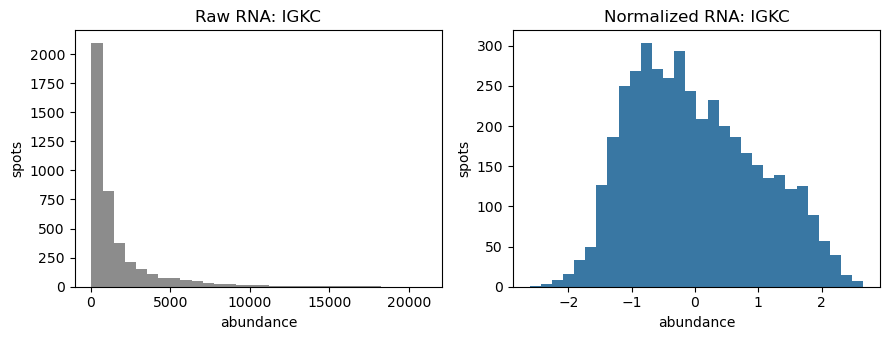

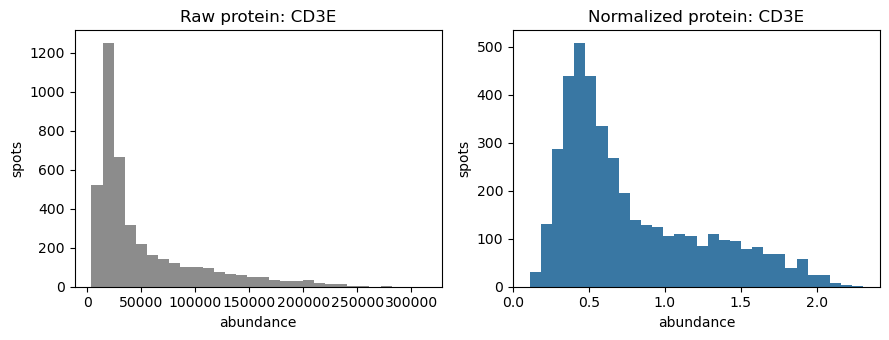

In [10]:
rna_feature = filtered_rna.var(axis=0).idxmax()
protein_feature = filtered_protein.var(axis=0).idxmax()
rna_fig, _ = plot_raw_vs_normalized(filtered_rna, rna_normalized, rna_feature, "RNA")
protein_fig, _ = plot_raw_vs_normalized(filtered_protein, protein_normalized, protein_feature, "protein")
rna_norm_path = paths.figures / "session01_rna_raw_vs_normalized.png"
protein_norm_path = paths.figures / "session01_protein_raw_vs_normalized.png"
rna_fig.savefig(rna_norm_path, dpi=160, bbox_inches="tight")
protein_fig.savefig(protein_norm_path, dpi=160, bbox_inches="tight")
plt.show()


### 4. Save processed matrices and a QC audit trail


In [11]:
qc_path = paths.results / "session01_spot_qc.csv"
filtering_path = paths.results / "session01_filtering_summary.csv"
filtered_spots_path = paths.processed_data / "filtered_spots.csv"
filtered_rna_path = paths.processed_data / "filtered_rna_counts.csv"
filtered_protein_path = paths.processed_data / "filtered_protein_counts.csv"
rna_path = paths.processed_data / "rna_log_normalized.csv"
protein_path = paths.processed_data / "protein_clr_normalized.csv"
processed_manifest_path = paths.processed_data / "session01_preprocessing_outputs.csv"

qc_before.assign(kept=keep_mask).to_csv(qc_path)
filtering_summary.to_csv(filtering_path, index=False)
filtered_spots.to_csv(filtered_spots_path)
filtered_rna.to_csv(filtered_rna_path)
filtered_protein.to_csv(filtered_protein_path)
rna_normalized.to_csv(rna_path)
protein_normalized.to_csv(protein_path)

processed_outputs = pd.DataFrame([
    {
        "artifact": path.name,
        "stage": stage,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "description": description,
    }
    for path, stage, table, description in [
        (filtered_spots_path, "filtered", filtered_spots, "Aligned spot metadata and x/y coordinates"),
        (filtered_rna_path, "filtered", filtered_rna, "RNA counts after spot and gene filtering"),
        (filtered_protein_path, "filtered", filtered_protein, "ADT counts after spot and isotype filtering"),
        (rna_path, "normalized", rna_normalized, "DGAT library-size/log1p/gene-scaled RNA"),
        (protein_path, "normalized", protein_normalized, "DGAT CLR-normalized protein values"),
    ]
])
processed_outputs.to_csv(processed_manifest_path, index=False)

processed_artifacts = [
    filtered_spots_path,
    filtered_rna_path,
    filtered_protein_path,
    rna_path,
    protein_path,
    processed_manifest_path,
]
manifest = write_checkpoint(
    "1.2",
    [qc_path, filtering_path, *processed_artifacts, qc_figure_path, rna_norm_path, protein_norm_path],
    summary={
        "spots_kept": len(filtered_spots),
        "spots_removed": int((~keep_mask).sum()),
        "processed_data_files": len(processed_artifacts),
    },
    start=paths.root,
)
print(f"Processed data saved under: {paths.processed_data}")
display(processed_outputs)
print(f"Checkpoint written: {manifest}")


Processed data saved under: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/data/processed


,artifact,stage,rows,columns,description
0,filtered_spots.csv,filtered,4191,3,Aligned spot metadata and x/y coordinates
1,filtered_rna_counts.csv,filtered,4191,17434,RNA counts after spot and gene filtering
2,filtered_protein_counts.csv,filtered,4191,31,ADT counts after spot and isotype filtering
3,rna_log_normalized.csv,normalized,4191,17434,DGAT library-size/log1p/gene-scaled RNA
4,protein_clr_normalized.csv,normalized,4191,31,DGAT CLR-normalized protein values


Checkpoint written: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_01/part_1_2.json


### Check

You should now be able to justify: (1) which spots/features were removed, (2) why RNA and protein
use different transforms, and (3) why filtered counts remain available alongside normalized matrices for QC and auditability. Confirm the six files listed above exist in `data/processed/`.
